In [34]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [35]:
df = pd.read_csv("../data/processed/glassdoor_jobs_cleaned.csv")

df.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Min Salary,Max Salary,Average Salary,Company Age,State
0,Data Scientist,53-91,"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),-1,53.0,91.0,72.0,53.0,NM
1,Healthcare Data Scientist,63-112,What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,63.0,112.0,87.5,42.0,MD
2,Data Scientist,80-90,"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,Security Services,Business Services,$100 to $500 million (USD),-1,80.0,90.0,85.0,16.0,FL
3,Data Scientist,56-97,*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),"Oak Ridge National Laboratory, National Renewa...",56.0,97.0,76.5,61.0,WA
4,Data Scientist,86-143,Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",86.0,143.0,114.5,28.0,NY


In [36]:
print("Shape:", df.shape)

df.info()

Shape: (956, 19)
<class 'pandas.DataFrame'>
RangeIndex: 956 entries, 0 to 955
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          956 non-null    str    
 1   Salary Estimate    956 non-null    str    
 2   Job Description    956 non-null    str    
 3   Rating             956 non-null    float64
 4   Company Name       956 non-null    str    
 5   Location           956 non-null    str    
 6   Headquarters       956 non-null    str    
 7   Size               956 non-null    str    
 8   Founded            956 non-null    int64  
 9   Type of ownership  956 non-null    str    
 10  Industry           956 non-null    str    
 11  Sector             956 non-null    str    
 12  Revenue            956 non-null    str    
 13  Competitors        956 non-null    str    
 14  Min Salary         742 non-null    float64
 15  Max Salary         742 non-null    float64
 16  Average Salary     7

In [37]:
df.isnull().sum().sort_values(ascending=False)

Min Salary           214
Average Salary       214
Max Salary           214
Company Age           97
Job Description        0
Job Title              0
Salary Estimate        0
Rating                 0
Company Name           0
Location               0
Headquarters           0
Industry               0
Type of ownership      0
Founded                0
Size                   0
Competitors            0
Revenue                0
Sector                 0
State                  0
dtype: int64

In [38]:
drop_cols = [
    "Salary Estimate",
    "Job Description",
    "Competitors",
    "Headquarters"
]

df.drop(columns=drop_cols, inplace=True, errors="ignore")

In [39]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [40]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [41]:
df.isnull().sum().sum()

np.int64(739)

In [42]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,Rating,Founded,Min Salary,Max Salary,Average Salary,Company Age,Job Title_AWS Data Engineer,Job Title_Advanced Analytics Manager,Job Title_Ag Data Scientist,Job Title_Analytics - Business Assurance Data Analyst,...,State_RI,State_SC,State_TN,State_TX,State_UT,State_United States,State_VA,State_Virginia,State_WA,State_WI
0,3.8,1973,53.0,91.0,72.0,53.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,3.4,1984,63.0,112.0,87.5,42.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,4.8,2010,80.0,90.0,85.0,16.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,3.8,1965,56.0,97.0,76.5,61.0,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,2.9,1998,86.0,143.0,114.5,28.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [43]:
X = df.drop("Average Salary", axis=1)

y = df["Average Salary"]

In [44]:
print("NaN in X =", X.isnull().sum().sum())

print("NaN in y =", y.isnull().sum())

NaN in X = 525
NaN in y = 214


In [45]:
X = X.fillna(0)
y = y.fillna(y.median())

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(764, 1178)
(192, 1178)


In [47]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [48]:
def evaluate_model(model_name, y_test, prediction):

    print("="*40)
    print(model_name)

    print("MAE :", mean_absolute_error(y_test, prediction))

    print("RMSE :", np.sqrt(mean_squared_error(y_test, prediction)))

    print("R2 Score :", r2_score(y_test, prediction))

In [49]:
evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
)

Linear Regression
MAE : 8.14055860699107
RMSE : 18.203114277136542
R2 Score : 0.7323911829540835


In [50]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)

Decision Tree
MAE : 0.6380208333333334
RMSE : 1.5938521209112637
R2 Score : 0.9979483414873074


In [51]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

Random Forest
MAE : 0.5124826388888887
RMSE : 1.2152104822637535
R2 Score : 0.9988073526672704


In [52]:
gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

evaluate_model(
    "Gradient Boosting",
    y_test,
    gb_pred
)

Gradient Boosting
MAE : 1.0534116317748865
RMSE : 3.009072466325174
R2 Score : 0.9926873578603645


In [53]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "R2":[
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred)
    ],

    "MAE":[
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, gb_pred)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, gb_pred))
    ]

})

results.sort_values("R2", ascending=False)

,Model,R2,MAE,RMSE
2,Random Forest,0.998807,0.512483,1.215210
1,Decision Tree,0.997948,0.638021,1.593852
3,Gradient Boosting,0.992687,1.053412,3.009072
0,Linear Regression,0.732391,8.140559,18.203114


In [54]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
3,Max Salary,0.836006
2,Min Salary,0.159643
1,Founded,0.000382
4,Company Age,0.000379
0,Rating,0.000370
826,"Location_Chicago, IL",0.000126
1136,State_CA,0.000123
1145,State_IL,0.000103
1110,Sector_Insurance,0.000102
122,"Job Title_Director II, Data Science - GRM Actu...",0.000101


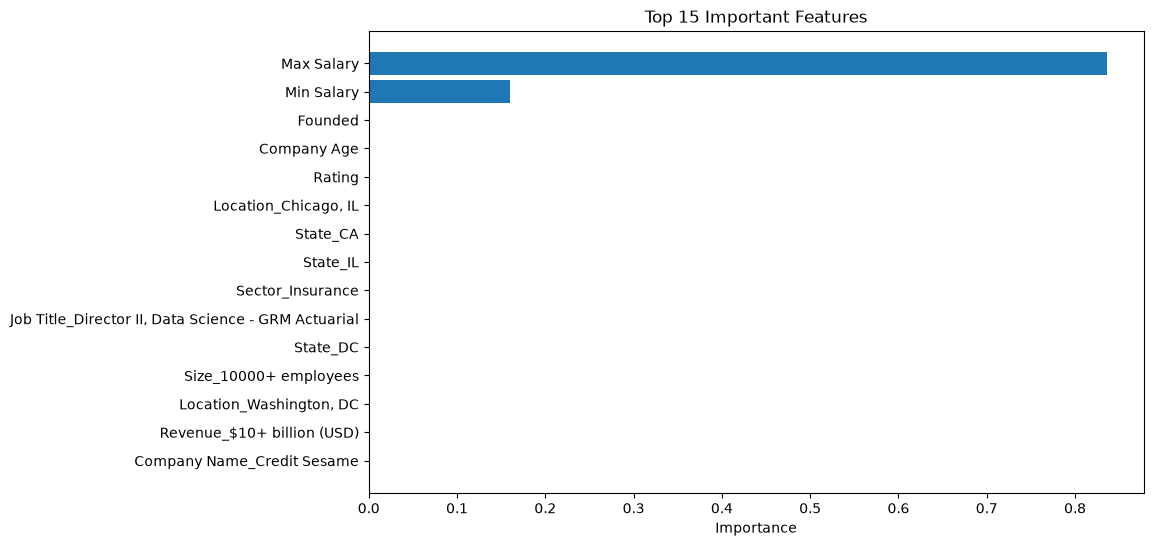

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.xlabel("Importance")

plt.show()

In [56]:
joblib.dump(
    rf,
    "../models/random_forest_model.pkl"
)

print("Model Saved")

Model Saved


In [57]:
joblib.dump(
    X.columns.tolist(),
    "../models/model_columns.pkl"
)

print("Columns Saved")

Columns Saved


In [58]:
print(X.isnull().sum().sum())
print(y.isnull().sum())
print(X.shape)

0
0
(956, 1178)


In [59]:
print(X.isnull().sum().sum())
print(y.isnull().sum())
print(X.shape)
print(y.shape)

0
0
(956, 1178)
(956,)
